# 03 — How good is the hallucination checker?

**The claim behind Novelty 2:** an NLI cross-encoder can tell, sentence by sentence, whether an answer is
supported by the retrieved evidence. This notebook measures that on **36 labelled claims**
(`data/eval/metformin_claims.json`): 12 questions × {a faithful paraphrase, a contradiction, a plausible
invention}.

**Realistic evidence, not hand-picked.** Each claim is checked against *the passages the app itself
retrieves for its question* (layout-aware chunks + re-ranking, top 5). So an error can come from two
places — retrieval missed the evidence, or NLI misjudged it — and the notebook tells them apart.

**What matters for the UI:** a claim is *flagged* (amber/red) when it is not grounded. Two error types
have very different costs: a **missed hallucination** (false green) misleads the reader; a **false alarm**
(true fact painted amber) erodes trust in the colours. We report both.

**Known bias:** one annotator wrote the claims, knowing how NLI models behave; 36 claims is small
(one claim ≈ 3 percentage points).

In [1]:
# Setup — make `config` and `src` importable from notebooks/, quiet the logs, apply the chart style.
import os, sys, warnings
from pathlib import Path
os.environ["TQDM_DISABLE"] = "1"                 # no progress bars in saved outputs
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "notebooks")]
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()                 # hide HuggingFace load chatter
from huggingface_hub.utils import logging as hub_logging
hub_logging.set_verbosity_error()                # ...and Hub server notices

import _viz                                      # shared chart style (notebooks/_viz.py)
_viz.apply()
PDF = ROOT / "data" / "samples" / "metformin_er_fda_label.pdf"

## 1. The pipeline under test

In [2]:
import contextlib, io, json, tempfile         # stdlib: quiet progress bars, load eval data, temp index

import pandas as pd                           # pandas: result tables (the twin of every chart)

from src.chunker import chunk_regions
from src.embedder import Embedder
from src.generator import GeneratedAnswer
from src.hallucination import CONTRADICTED, GROUNDED, UNSUPPORTED, HallucinationChecker
from src.ingestion import load_pdf_pages
from src.layout import LayoutDetector
from src.reranker import Reranker
from src.retriever import Retriever
from src.vectorstore import VectorStore

chunks = chunk_regions(LayoutDetector().detect_document(load_pdf_pages(PDF)), doc_id="label")
embedder = Embedder()
store = VectorStore(persist_dir=tempfile.mkdtemp(), collection_name="eval")
with contextlib.redirect_stderr(io.StringIO()):
    store.add_chunks(chunks, embedder.embed_chunks(chunks))
retriever = Retriever(embedder, store, reranker=Reranker())
checker = HallucinationChecker()

[LayoutDetector] Loading model: Kwan0/layoutlmv3-base-finetune-DocLayNet-100k
[LayoutDetector] First run downloads ~500MB — be patient.


[LayoutDetector] Ready on cuda. Labels: ['caption', 'footnote', 'formula', 'list_item', 'page_footer', 'page_header', 'picture', 'section_header', 'table', 'text', 'title']


[Embedder] Loading model: sentence-transformers/all-MiniLM-L6-v2


[Embedder] Ready on cuda:0. dim=384, max_seq_length=256
[VectorStore] Collection 'eval' at /tmp/tmprlc91g3v (0 chunks)


[Reranker] Loading model: cross-encoder/ms-marco-MiniLM-L-6-v2


[Reranker] Ready on cuda:0.
[HallucinationChecker] Loading model: cross-encoder/nli-deberta-v3-small


[HallucinationChecker] Ready on cuda. entailment=1, contradiction=0


## 2. The labelled claims

In [3]:
EVAL = ROOT / "data" / "eval"
CLAIMS = json.load(open(EVAL / "metformin_claims.json"))["items"]
GOLD_EVIDENCE = {q["q"]: q["gold"] for q in json.load(open(EVAL / "metformin_questions.json"))["questions"]}
pd.DataFrame([{"question": i["q"], "claim": c["text"], "gold": c["gold"]}
              for i in CLAIMS for c in i["claims"]]).head(6)

,question,claim,gold
0,What is the starting dose?,The usual starting dose is 500 mg taken once a...,grounded
1,What is the starting dose?,"The starting dose is 1,000 mg taken twice daily.",contradicted
2,What is the starting dose?,The starting dose does not need to be adjusted...,unsupported
3,What is the maximum daily dose?,"The dose should not exceed 2,000 mg per day.",grounded
4,What is the maximum daily dose?,"The maximum daily dose is 3,000 mg.",contradicted
5,What is the maximum daily dose?,The maximum dose was established in a trial of...,unsupported


## 3. Verify every claim against what the app retrieves

For each claim we record the sentence-level verdict (the shipped method) and, as an **ablation**, the
verdict when whole passages are the premises — the method this project started with before the
SummaC-style fix.

In [4]:
import re
import time

norm = lambda t: re.sub(r"\s+", " ", t).strip().lower()


def verdict(entail: float, contra: float, threshold: float = 0.5) -> str:
    """The checker's decision rule: support wins; otherwise refutation; otherwise unsupported."""
    return GROUNDED if entail >= threshold else CONTRADICTED if contra >= threshold else UNSUPPORTED


rows, start = [], time.perf_counter()
for item in CLAIMS:
    hits = retriever.retrieve(item["q"])
    found = any(g in norm(h.text) for h in hits for g in GOLD_EVIDENCE[item["q"]])
    for claim in item["claims"]:
        [v] = checker.verify(GeneratedAnswer(item["q"], claim["text"], hits, model="eval")).claims
        whole = checker.score_pairs([h.text for h in hits], [v.text] * len(hits))
        e_whole, c_whole = whole[:, checker.entail_idx].max(), whole[:, checker.contra_idx].max()
        rows.append({"question": item["q"], "claim": claim["text"], "gold": claim["gold"],
                     "pred": v.status, "entail": v.entailment, "contra": v.contradiction,
                     "evidence": " ".join(v.evidence.split())[:120], "evidence_retrieved": found,
                     "pred_whole": verdict(e_whole, c_whole), "entail_whole": float(e_whole)})
elapsed = time.perf_counter() - start
df = pd.DataFrame(rows)
print(f"{len(df)} claims verified in {elapsed:.1f} s ({elapsed / len(df) * 1000:.0f} ms per claim, "
      f"on {checker.device}); evidence retrieved for {df.groupby('question')['evidence_retrieved'].first().sum()}"
      f" of {len(CLAIMS)} questions")

36 claims verified in 4.2 s (117 ms per claim, on cuda); evidence retrieved for 11 of 12 questions


## 4. Results

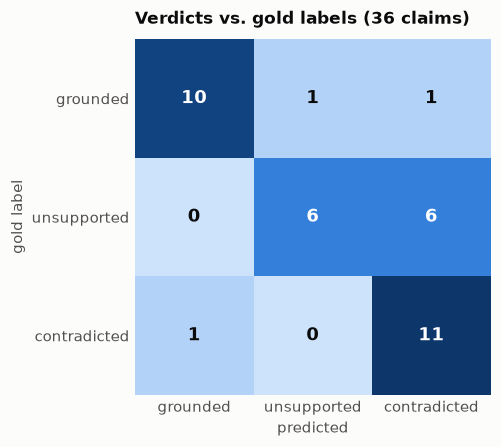

pred,grounded,unsupported,contradicted
gold,,,
grounded,10,1,1
unsupported,0,6,6
contradicted,1,0,11


In [5]:
import matplotlib.pyplot as plt               # matplotlib: static figures that render on GitHub
import numpy as np                            # numpy: metric arithmetic
from matplotlib.colors import LinearSegmentedColormap

ORDER = [GROUNDED, UNSUPPORTED, CONTRADICTED]
cm = pd.crosstab(df["gold"], df["pred"]).reindex(index=ORDER, columns=ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.imshow(cm.to_numpy(), cmap=LinearSegmentedColormap.from_list("seq", _viz.SEQ_BLUE), vmin=0)
for (i, j), n in np.ndenumerate(cm.to_numpy()):
    ax.text(j, i, str(n), ha="center", va="center", fontsize=12, fontweight="bold",
            color="white" if n > cm.to_numpy().max() / 2 else _viz.INK)
ax.set_xticks(range(3), ORDER)
ax.set_yticks(range(3), ORDER)
ax.set_xlabel("predicted")
ax.set_ylabel("gold label")
ax.grid(False)
ax.spines[:].set_visible(False)
ax.set_title("Verdicts vs. gold labels (36 claims)")
plt.show()
cm

In [6]:
def flag_metrics(pred: pd.Series, gold: pd.Series) -> dict:
    """Binary view the UI cares about: is a claim flagged (not grounded)?"""
    flagged, bad = pred != GROUNDED, gold != GROUNDED
    tp, fp, fn = (flagged & bad).sum(), (flagged & ~bad).sum(), (~flagged & bad).sum()
    precision = tp / (tp + fp) if tp + fp else 1.0
    recall = tp / (tp + fn) if tp + fn else 1.0
    return {"3-class accuracy": (pred == gold).mean(),
            "hallucinations caught (recall)": recall,
            "flags that were right (precision)": precision,
            "F1": 2 * precision * recall / (precision + recall) if precision + recall else 0.0,
            "true facts kept green": (~flagged & ~bad).sum() / (~bad).sum()}


summary = pd.DataFrame({"sentence-level (shipped)": flag_metrics(df["pred"], df["gold"]),
                        "whole-passage (ablation)": flag_metrics(df["pred_whole"], df["gold"])})
summary.round(3)

,sentence-level (shipped),whole-passage (ablation)
3-class accuracy,0.750,0.778
hallucinations caught (recall),0.958,0.958
flags that were right (precision),0.920,0.885
F1,0.939,0.920
true facts kept green,0.833,0.750


## 5. Is 0.5 the right threshold?

A claim is grounded when its best entailment ≥ threshold. Sweeping the threshold shows the trade-off
between catching hallucinations and keeping true facts green. **Caution:** picking the best threshold on
the same 36 claims would overfit — this chart is for seeing whether 0.5 sits on a plateau, not for tuning.

claims with best entailment between 0.1 and 0.9: 3 of 36


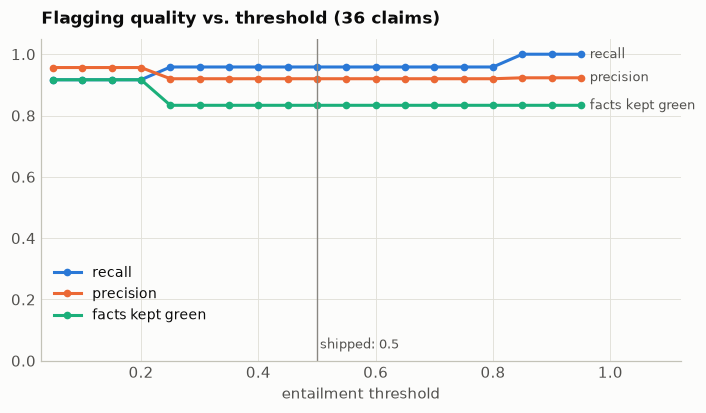

,hallucinations caught (recall),flags that were right (precision),F1,true facts kept green
threshold,,,,
0.1,0.917,0.957,0.936,0.917
0.3,0.958,0.920,0.939,0.833
0.5,0.958,0.920,0.939,0.833
0.7,0.958,0.920,0.939,0.833
0.9,1.000,0.923,0.960,0.833


In [7]:
thresholds = np.round(np.arange(0.05, 0.96, 0.05), 2)
# Binary metrics only: at a given threshold we know flag / no flag, not which of the two flag colours.
binary = ["hallucinations caught (recall)", "flags that were right (precision)", "F1", "true facts kept green"]
sweep = pd.DataFrame([{"threshold": t, **flag_metrics(df["entail"].lt(t).map({True: "flag", False: GROUNDED}),
                                                       df["gold"])} for t in thresholds]).set_index("threshold")[binary]
print(f"claims with best entailment between 0.1 and 0.9: {df['entail'].between(0.1, 0.9).sum()} of {len(df)}")
lines = [("hallucinations caught (recall)", "recall"), ("flags that were right (precision)", "precision"),
         ("true facts kept green", "facts kept green")]

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for (col, short), color in zip(lines, _viz.SERIES):
    ax.plot(sweep.index, sweep[col], color=color, marker="o", markersize=4, label=short)
    ax.text(0.965, sweep[col].iloc[-1], short, color=_viz.INK_2, fontsize=8.5, va="center")
ax.axvline(0.5, color=_viz.MUTED, linewidth=0.9)
ax.text(0.505, 0.04, "shipped: 0.5", color=_viz.INK_2, fontsize=8.5)
ax.set_xlim(0.03, 1.12)
ax.set_ylim(0, 1.05)
ax.set_xlabel("entailment threshold")
ax.set_title("Flagging quality vs. threshold (36 claims)")
ax.legend(loc="lower left", bbox_to_anchor=(0.0, 0.08))
plt.show()
sweep.loc[[0.1, 0.3, 0.5, 0.7, 0.9]].round(3)

## 6. Ablation — does sentence-level NLI matter?

Same claims, same retrieved passages; only the premise granularity changes.

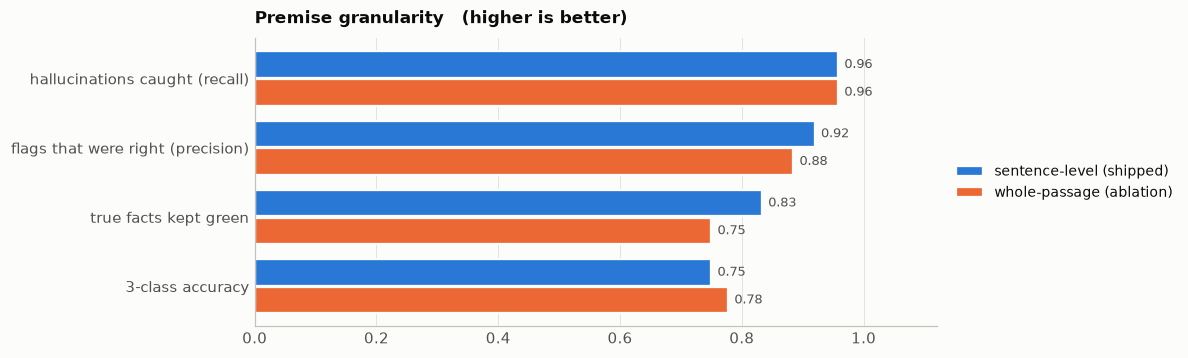

In [8]:
show = ["hallucinations caught (recall)", "flags that were right (precision)", "true facts kept green",
        "3-class accuracy"]
fig, ax = plt.subplots(figsize=(8, 3.4))
y = np.arange(len(show))[::-1]
for k, (name, color) in enumerate([("sentence-level (shipped)", _viz.SERIES[0]),
                                   ("whole-passage (ablation)", _viz.SERIES[1])]):
    vals = summary.loc[show, name].to_numpy()
    ax.barh(y + (0.2 - 0.4 * k), vals, height=0.38, color=color, edgecolor=_viz.SURFACE,
            linewidth=1.5, label=name)
    for yi, v in zip(y + (0.2 - 0.4 * k), vals):
        ax.text(v + 0.01, yi, f"{v:.2f}", va="center", fontsize=8.5, color=_viz.INK_2)
ax.set_yticks(y, show)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, 1.12)
ax.set_title("Premise granularity   (higher is better)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.show()

In [9]:
# Why is the difference so small here? Count how many retrieved passages are a single sentence —
# for those, "whole passage" and "sentence" are literally the same premise.
from src.hallucination import premise_units

passages = [h for item in CLAIMS for h in retriever.retrieve(item["q"])]
single = sum(len(premise_units(h)) == 1 for h in passages)
print(f"{single} of {len(passages)} retrieved passages ({single / len(passages):.0%}) are a single sentence or row")

7 of 60 retrieved passages (12%) are a single sentence or row


In [10]:
# The claims where the two premise granularities disagree.
diff = df[df["pred"] != df["pred_whole"]]
diff[["claim", "gold", "pred", "entail", "pred_whole", "entail_whole"]].round(3)

,claim,gold,pred,entail,pred_whole,entail_whole
2,The starting dose does not need to be adjusted...,unsupported,contradicted,0.001,unsupported,0.001
5,The maximum dose was established in a trial of...,unsupported,contradicted,0.035,unsupported,0.035
18,Vitamin B12 levels should be measured every 2 ...,grounded,grounded,0.984,contradicted,0.001
19,Vitamin B12 levels should be measured every week.,contradicted,contradicted,0.001,unsupported,0.001
35,One glass of red wine per day lowers the risk ...,unsupported,contradicted,0.000,unsupported,0.000


## 7. Every error, with its evidence

`evidence_retrieved = False` means retrieval never gave NLI a passage containing the fact — a retrieval
error, not an NLI error.

In [11]:
errors = df[df["gold"] != df["pred"]][["question", "claim", "gold", "pred", "entail", "contra",
                                       "evidence_retrieved", "evidence"]]
pd.set_option("display.max_colwidth", 90)
errors.round(3)

,question,claim,gold,pred,entail,contra,evidence_retrieved,evidence
1,What is the starting dose?,"The starting dose is 1,000 mg taken twice daily.",contradicted,grounded,0.823,1.000,True,", or meglitinides), and patients (n=368) receiving metformin HCl tablets up to 1,500 m..."
2,What is the starting dose?,The starting dose does not need to be adjusted for body weight.,unsupported,contradicted,0.001,0.830,True,"Following a single oral dose of 1,000 mg (2x500 mg tablets) metformin hydrochloride ex..."
3,What is the maximum daily dose?,"The dose should not exceed 2,000 mg per day.",grounded,contradicted,0.229,0.965,True,Increase the dose in increments of 500 mg every 1 to 2 weeks on the basis of glycemic ...
5,What is the maximum daily dose?,"The maximum dose was established in a trial of 3,000 patients.",unsupported,contradicted,0.035,0.992,True,", or meglitinides), and patients (n=368) receiving metformin HCl tablets up to 1,500 m..."
17,How should suspected lactic acidosis be treated?,Suspected lactic acidosis should be treated with intravenous insulin.,unsupported,contradicted,0.000,0.999,True,Hemodialysis has often resulted in reversal of symptoms and recovery.
21,What are the most common side effects?,Diarrhea and nausea are among the most common adverse reactions.,grounded,unsupported,0.002,0.023,False,• feel very weak and tired • have unusual sleepiness or sleep longer than usual • have...
26,Is it safe for children?,Children should take the tablets only with milk.,unsupported,contradicted,0.001,0.996,True,"However, there is insufficient information to determine the effects of metformin on th..."
29,How does metformin work?,Metformin works by blocking carbohydrate digestion in the stomach.,unsupported,contradicted,0.014,0.918,True,"Metformin decreases hepatic glucose production, decreases intestinal absorption of glu..."
35,Can I drink alcohol while taking metformin?,One glass of red wine per day lowers the risk of side effects.,unsupported,contradicted,0.000,0.992,True,against excessive alcohol intake while receiving metformin hydrochloride extended-rele...


## Findings

**Flagging works.** 23 of 24 hallucinations are flagged (recall 0.96), 23 of 25 flags are right
(precision 0.92), and 10 of 12 true facts stay green — on evidence the app itself retrieved.

**The colour of a flag is unreliable.** Half of the invented claims (6 of 12) are called *contradicted*
instead of *unsupported*: NLI reads a different number or topic as refutation. For the reader both mean
"not supported by this document", and red claims already show the passage that "contradicts" them, so a
spurious red is visible as one. That is why 3-class accuracy (0.75) is much lower than flagging F1 (0.94).

**The threshold barely matters.** Only 3 of 36 claims have a best entailment between 0.1 and 0.9 —
DeBERTa's scores are near 0 or near 1 — so recall and precision are flat from 0.25 to 0.8. 0.5 stays;
nothing was tuned on these 36 claims.

**Every error, explained** (section 7):
* *Missed hallucination* — "The starting dose is 1,000 mg taken twice daily": entailment 0.82 from a
  clinical-trial sentence about patients on 1,000 mg twice daily **and** contradiction 1.00 from the dosing
  section. Conflicting evidence; the rule "support beats refutation" resolved it as green. A *conflict*
  state (both scores high) would catch it.
* *False alarm* — "The dose should not exceed 2,000 mg per day" vs "up to a maximum of 2,000 mg":
  a negated paraphrase scored entailment 0.23. NLI models are known to struggle with negation.
* *False alarm* — "Diarrhea and nausea are among the most common adverse reactions": the evidence was
  never retrieved (the heading-split-from-list case from notebook 02). A retrieval error, not an NLI error.

**Sentence-level vs. whole-passage premises: a trade-off, not a free win.**
* It *fixes entailment*: "Vitamin B12 levels should be measured every 2 to 3 years" scores 0.984 against
  the sentence and **0.001** against the full passage — the same collapse the unit test pins, now on real
  retrieved text. True facts kept green: 0.83 vs 0.75.
* It *inflates contradictions*: with more premises there are more chances for a spurious refutation, so
  three invented claims flip from the correct *unsupported* to *contradicted*.
* Hypothesis for future work (not shipped — it would be tuned on the same 36 claims it is judged on):
  take **entailment from sentences, contradiction from whole passages**. On this set: +3 labels right, −1.

> **INTERVIEW ALERT — "How well does your hallucination detector work?"**
> "On 36 labelled claims checked against real retrieved evidence, it flags 23 of 24 hallucinations and
> keeps 10 of 12 true facts green. It's reliable at *supported or not* and unreliable at *unsupported vs
> contradicted* — so the UI treats both as a warning and shows the evidence. Its one miss was conflicting
> evidence: one sentence supported the claim, another refuted it, and my rule let support win."

**Limits.** 36 claims, one document, one annotator; one claim ≈ 3 percentage points.

Computed summary:

In [12]:
s = summary["sentence-level (shipped)"]
w = summary["whole-passage (ablation)"]
missed = df[(df["gold"] != GROUNDED) & (df["pred"] == GROUNDED)]
alarms = df[(df["gold"] == GROUNDED) & (df["pred"] != GROUNDED)]
print(f"* 3-class accuracy {s['3-class accuracy']:.2f}; hallucinations caught {s['hallucinations caught (recall)']:.2f}; "
      f"flags right {s['flags that were right (precision)']:.2f}; true facts kept green {s['true facts kept green']:.2f}.")
print(f"* Missed hallucinations (false green): {len(missed)}   |   false alarms on true facts: {len(alarms)} "
      f"({int((~alarms['evidence_retrieved']).sum())} of them retrieval misses).")
print(f"* Whole-passage ablation: facts kept green {w['true facts kept green']:.2f} vs {s['true facts kept green']:.2f}; "
      f"accuracy {w['3-class accuracy']:.2f} vs {s['3-class accuracy']:.2f}.")
print(f"* Cost: {elapsed / len(df) * 1000:.0f} ms per claim on {checker.device}.")

* 3-class accuracy 0.75; hallucinations caught 0.96; flags right 0.92; true facts kept green 0.83.
* Missed hallucinations (false green): 1   |   false alarms on true facts: 2 (1 of them retrieval misses).
* Whole-passage ablation: facts kept green 0.75 vs 0.83; accuracy 0.78 vs 0.75.
* Cost: 117 ms per claim on cuda.
